In [69]:
!pip install --user ipympl
!pip install --user --upgrade jupyter matplotlib
!pip install --user scipy
from scipy.ndimage import uniform_filter


# Configuration cell (run SECOND)
import matplotlib
matplotlib.use('module://ipympl.backend_nbagg')  # VS Code specific backend
%matplotlib widget

import pandas as pd
import numpy as np
import matplotlib
import os

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from helpers.load import *

scenario_parent_folder = Path(os.path.abspath('')) / 'logs' /  'unified' / 'buoy'

Ran with 
```
# Independent variables
independent_vars = {
    "nodeXCount" : list(np.arange(1, 26, 1)),
    "nodeYCount" : list(np.arange(1, 26, 1)),
    "nodeZCount": [1],
    "nodeZSpacing": [1],
    "nodeZOffset": list(np.arange(0, -1.8, -0.1)),
    "auvSpeed": [0],
    "propagationModel": ["underwater"],
    "waterTemperature": [20],
    "waterSalinity": [0.01],
    "stopTime": [10*60],  # seconds
    "channelWidth": [1],
    "scenarioFolderPath": ["\"unified/buoy/run\""]
}

# Dependent variables defined via lambda functions. 
# Each lambda receives a dict with the current independent variables.
dependent_vars = {
    # 1.8 because otherwise we'll have nodes out of range
    "nodeXSpacing": lambda args: 1.8 / (args["nodeXCount"] - 1) if args["nodeXCount"] > 1 else 1,
    "nodeXOffset": lambda args: -args["nodeXSpacing"] * (args["nodeXCount"] - 1) / 2,
    "nodeYSpacing": lambda args: 1.8 / (args["nodeYCount"] - 1) if args["nodeYCount"] > 1 else 1,
    "nodeYOffset": lambda args: -args["nodeYSpacing"] * (args["nodeYCount"] - 1) / 2,
    "dataRatePHY": lambda args: "OfdmRate1_2MbpsBW1MHz" if args["channelWidth"] == 1 else "OfdmRate7_8MbpsBW2MHz",
}
```

In [70]:
def read_sim_config_file(scenario_folder:Path) -> dict:
    sim_config = {}
    with open(scenario_folder / 'SimConfig.txt') as f:
        for line in f:
            if line.startswith('--'):
                key, value = line.strip().split('=')
                key = key[2:]  # Remove the leading '--'
                
                # Try to convert value to appropriate data type
                try:
                    # First try as int
                    sim_config[key] = int(value)
                except ValueError:
                    try:
                        # Then try as float
                        sim_config[key] = float(value)
                    except ValueError:
                        # Keep as string if not numeric
                        sim_config[key] = value
    return sim_config

In [71]:
# Get all the scenario folders
scenario_folders = sorted([x for x in scenario_parent_folder.iterdir() if x.is_dir()])
print(f"Will load {len(scenario_folders)} scenario runs")

packet_flow_stats = pd.DataFrame()
power_state_stats = pd.DataFrame()
for i, scenario_folder in enumerate(scenario_folders):
    sim_config = read_sim_config_file(scenario_folder)
    print(f"[{i+1}/{len(scenario_folders)}] Loading scenario {scenario_folder.name}")

    # Load the flow monitor stats
    if (scenario_folder / 'FlowMonitor.xml').exists():
        fm_temp_df = load_flow_monitor_xml(scenario_folder / 'FlowMonitor.xml')
        
        if not fm_temp_df.empty:
            # Take into account only STA->AP traffic
            fm_temp_df = fm_temp_df[fm_temp_df['destinationPort'] == "84"]
            
            # Calculate throughput per-flow
            fm_temp_df['Throughput'] = fm_temp_df['rxBytes'] * 8 / ((fm_temp_df['timeLastRxPacket'] - fm_temp_df['timeFirstTxPacket']) / 1e9) * (1 / 10**6)  # Mbps
            
            # Calculate the mean latency per-flow
            fm_temp_df['MeanLatency'] = fm_temp_df['delaySum'] / fm_temp_df['rxPackets']  # ns
            
            packet_flow_stats.loc[i, 'Throughput'] = fm_temp_df['Throughput'].mean()
            packet_flow_stats.loc[i, 'Latency'] = fm_temp_df['MeanLatency'].mean()
            packet_flow_stats.loc[i, 'rxBytes'] = fm_temp_df['rxBytes'].sum()
        else:
            print(f"FlowMonitor.xml does not contain any flows in {scenario_folder.name}")
            packet_flow_stats.loc[i, 'Throughput'] = np.nan
            packet_flow_stats.loc[i, 'Latency'] = np.nan
            packet_flow_stats.loc[i, 'rxBytes'] = 0
        
        for key, value in sim_config.items():
            packet_flow_stats.loc[i, key] = value
    else:
        print(f"FlowMonitor.xml not found in {scenario_folder.name}")
        
    # Load the power state stats
    if (scenario_folder / 'PowerStateStats.csv').exists():
        ps_temp_df = pd.read_csv(scenario_folder / 'PowerStateStats.csv', delimiter=';', index_col=False)
        for col in ['SLEEPTime', 'IDLETime', 'TXTime', 'RXTime', 'CCA_BUSYTime', 'SWITCHINGTime', 'SLEEPEnergy', 'IDLEEnergy', 'TXEnergy', 'RXEnergy', 'CCA_BUSYEnergy', 'SWITCHINGEnergy', 'TotalEnergy']:
            # Check if the column contains string values
            if ps_temp_df[col].dtype == 'object':
                # If strings, replace 'ns' and convert to float
                ps_temp_df[col] = ps_temp_df[col].str.replace('ns', '').astype(float)
            # Ignore the APs as we assume they are always on
            power_state_stats.loc[i, col] = ps_temp_df[ps_temp_df['NodeType'] == "STA"][col].mean()
        for key, value in sim_config.items():
            power_state_stats.loc[i, key] = value
    else:
        print(f"PowerStateStats.csv not found in {scenario_folder.name}")

Will load 1887 scenario runs
[1/1887] Loading scenario run_1743355140600362285
[2/1887] Loading scenario run_1743355140600362407
[3/1887] Loading scenario run_1743355140600362473
[4/1887] Loading scenario run_1743355140600363379
[5/1887] Loading scenario run_1743355140600476632
[6/1887] Loading scenario run_1743355140600830585
[7/1887] Loading scenario run_1743355140602350526
[8/1887] Loading scenario run_1743355140603443818
[9/1887] Loading scenario run_1743355140603487972
[10/1887] Loading scenario run_1743355140603644955
[11/1887] Loading scenario run_1743355140603801830
[12/1887] Loading scenario run_1743355140604188407
[13/1887] Loading scenario run_1743355158230247573
[14/1887] Loading scenario run_1743355158283123699
[15/1887] Loading scenario run_1743355158513195213
[16/1887] Loading scenario run_1743355158514217553
[17/1887] Loading scenario run_1743355158514275472
[18/1887] Loading scenario run_1743355158514760628
[19/1887] Loading scenario run_1743355158518777885
[20/1887] L

In [92]:
packet_flow_stats

,Throughput,Latency,rxBytes,nodeXCount,nodeYCount,nodeZCount,nodeZSpacing,nodeZOffset,auvSpeed,propagationModel,waterTemperature,waterSalinity,stopTime,channelWidth,scenarioFolderPath,nodeXSpacing,nodeXOffset,nodeYSpacing,nodeYOffset,dataRatePHY
0,0.232365,1.016415e+08,17397852.0,1.0,1.0,1.0,1.0,0.0,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
1,0.231519,1.012098e+08,17333172.0,1.0,1.0,1.0,1.0,-0.3,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
2,0.231519,1.012098e+08,17333172.0,1.0,1.0,1.0,1.0,-0.4,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
3,0.231519,1.012097e+08,17333172.0,1.0,1.0,1.0,1.0,-0.1,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
4,0.231799,1.013680e+08,17355516.0,1.0,1.0,1.0,1.0,-0.2,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872,0.000096,5.771119e+07,205428.0,14.0,14.0,1.0,1.0,0.0,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,0.138462,-0.9,0.138462,-0.9,OfdmRate1_2MbpsBW1MHz
1874,0.000251,5.730929e+08,898656.0,14.0,14.0,1.0,1.0,-0.2,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,0.138462,-0.9,0.138462,-0.9,OfdmRate1_2MbpsBW1MHz
1875,0.000809,6.524375e+08,4549084.0,14.0,14.0,1.0,1.0,-0.3,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,0.138462,-0.9,0.138462,-0.9,OfdmRate1_2MbpsBW1MHz
1877,0.000046,2.581501e+07,94248.0,14.0,14.0,1.0,1.0,-0.5,0.0,underwater,20.0,0.01,600.0,1.0,unified/buoy/run,0.138462,-0.9,0.138462,-0.9,OfdmRate1_2MbpsBW1MHz


In [73]:
power_state_stats

,SLEEPTime,IDLETime,TXTime,RXTime,CCA_BUSYTime,SWITCHINGTime,SLEEPEnergy,IDLEEnergy,TXEnergy,RXEnergy,...,waterTemperature,waterSalinity,stopTime,channelWidth,scenarioFolderPath,nodeXSpacing,nodeXOffset,nodeYSpacing,nodeYOffset,dataRatePHY
0,1.543047e+11,1.940298e+11,1.710597e+11,8.060932e+10,0.000000e+00,0.0,15.276200,81.523000,205.063000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
1,1.540965e+11,1.953231e+11,1.700405e+11,8.054376e+10,0.000000e+00,0.0,15.255600,81.574800,203.893000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
2,1.540965e+11,1.953231e+11,1.700405e+11,8.054376e+10,0.000000e+00,0.0,15.255600,81.574800,203.893000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
3,1.540967e+11,1.953229e+11,1.700405e+11,8.054376e+10,0.000000e+00,0.0,15.255600,81.574800,203.893000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
4,1.543007e+11,1.948735e+11,1.703371e+11,8.049208e+10,0.000000e+00,0.0,15.275800,81.467200,204.254000,0.000000,...,20.0,0.01,600.0,1.0,unified/buoy/run,1.000000,0.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872,1.466847e+11,4.199294e+11,2.494531e+07,3.318674e+10,1.266211e+08,0.0,14.521790,65.461963,0.033733,0.007340,...,20.0,0.01,600.0,1.0,unified/buoy/run,0.138462,-0.9,0.138462,-0.9,OfdmRate1_2MbpsBW1MHz
1874,1.463155e+11,4.123984e+11,9.435837e+07,4.036473e+10,7.793012e+08,0.0,14.485280,71.296421,0.116048,0.047811,...,20.0,0.01,600.0,1.0,unified/buoy/run,0.138462,-0.9,0.138462,-0.9,OfdmRate1_2MbpsBW1MHz
1875,1.455023e+11,3.710685e+11,4.421310e+08,8.058186e+10,2.357544e+09,0.0,14.404798,104.056770,0.469224,0.141374,...,20.0,0.01,600.0,1.0,unified/buoy/run,0.138462,-0.9,0.138462,-0.9,OfdmRate1_2MbpsBW1MHz
1877,1.467499e+11,4.208664e+11,1.814449e+07,3.228917e+10,2.874407e+07,0.0,14.528239,64.726568,0.023606,0.001282,...,20.0,0.01,600.0,1.0,unified/buoy/run,0.138462,-0.9,0.138462,-0.9,OfdmRate1_2MbpsBW1MHz


missing pair: -1.7000000000000002, 182.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.7000000000000002, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.6, 182.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.6, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.5, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.4000000000000001, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.3, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.2000000000000002, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.1, 196.0, w

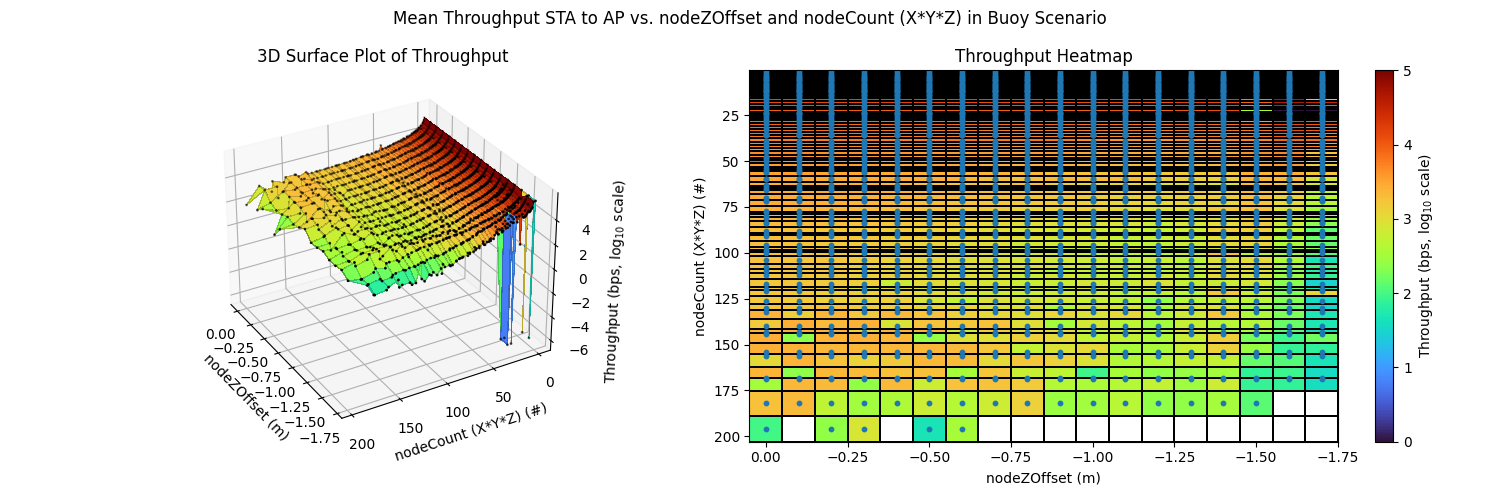

In [99]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean Throughput STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(packet_flow_stats['nodeZOffset'].unique())
y_unique = np.sort((packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount']).unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)


missing = []

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (packet_flow_stats['nodeZOffset'] == node_z_offset) & \
               (packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = packet_flow_stats.loc[mask, 'Throughput'].mean()
            if np.isnan(Z[j, i]):
                print(f"{node_z_offset}, {node_count} is a NaN, which implies that the nodes failed to connect (FlowMonitor file is empty)")
                Z[j, i] = 0
                #replace nans in the original data with the default value
                packet_flow_stats.loc[mask, 'Throughput'] = 0
            else:
                Z[j, i] = Z[j, i] * 1e+6
        else:
            print(f"missing pair: {node_z_offset}, {node_count}, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)")
            Z[j, i] = np.nan


#Z = uniform_filter(Z, size=2)  # Adjust size for more smoothing
# print("Z_smooth shape: ", Z.dtype)
# print("Before smoothing:", Z)
# print("After smoothing:", Z_smooth)
# print("Min/Max after smoothing:", np.min(Z_smooth), np.max(Z_smooth))
print(np.isnan(Z).sum())  # Count NaNs

epsilon = 1e-6  # Small constant to avoid log(0)
Z_log = np.log10(Z + epsilon)
Z = Z_log

# Isometric view (default 3D view)
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='turbo',
                        edgecolor=(0,0,0,0.2),  # Lighter edges
                        linewidth=0.1,  # Thinner lines
                        antialiased=False,
                        shade=True,  # Enable shading
                        alpha=1,
                        vmin=0,
                        vmax= 5)   # For smoother surface
ax1.view_init(elev=30, azim=150)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Throughput (bps, log$_{10}$ scale)')
ax1.set_title('3D Surface Plot of Throughput')

# Overlay the actual data points
ax1.scatter(packet_flow_stats['nodeZOffset'], 
           packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'],
           np.log10(packet_flow_stats['Throughput'] * 1e+6 + epsilon),
           color='black', s=1, label='Data Points')  # s = marker size




# --- 2D Heatmap ---
ax2 = fig.add_subplot(122)  # Right side for 2D heatmap
# Calculate edges halfway between centers
x_edges = np.concatenate([
    [x_unique[0] - np.diff(x_unique)[0]/2],  # Left edge of first bin
    x_unique[:-1] + np.diff(x_unique)/2,      # Midpoints between centers
    [x_unique[-1] + np.diff(x_unique)[-1]/2]  # Right edge of last bin
])
y_edges = np.concatenate([
    [y_unique[0] - np.diff(y_unique)[0]/2],
    y_unique[:-1] + np.diff(y_unique)/2,
    [y_unique[-1] + np.diff(y_unique)[-1]/2]
])

# Create meshgrid for edges
X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

heatmap = ax2.pcolormesh(
    X_edges,  # Grid edges (x-axis)
    Y_edges,  # Grid edges (y-axis)
    Z,  
    cmap='turbo',
    shading='flat',  # Smooths irregular grids
    antialiased= False,
    edgecolors='black',  # Avoids gaps between cells
    linewidth=0.1,
    vmin=0,
    vmax= 5
)

ax2.set_xlabel("nodeZOffset (m)")
ax2.set_ylabel("nodeCount (X*Y*Z) (#)")
ax2.set_title("Throughput Heatmap")
ax2.invert_xaxis()
ax2.invert_yaxis()
plt.colorbar(heatmap, ax=ax2, label='Throughput (bps, log$_{10}$ scale)')


# Overlay the actual data points on the heatmap
# Ensure 'x' and 'y' values are compatible with the grid from X and Y meshgrid

#Overlay the actual data points
ax2.scatter(
    packet_flow_stats['nodeZOffset'],  # Filtered X values
    packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'],  # Filtered Y values 
    s=10, 
    label='Data Points'
)

plt.tight_layout()
plt.show(block=True)

fig.savefig("Buoy_Throughput_graphs.svg", format="svg", dpi=300)

missing pair: -1.7000000000000002, 182.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.7000000000000002, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.6, 182.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.6, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.5, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.4000000000000001, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.3, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.2000000000000002, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.1, 196.0, w

C:\Users\20221907\AppData\Roaming\Python\Python38\site-packages\mpl_toolkits\mplot3d\proj3d.py:180: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w


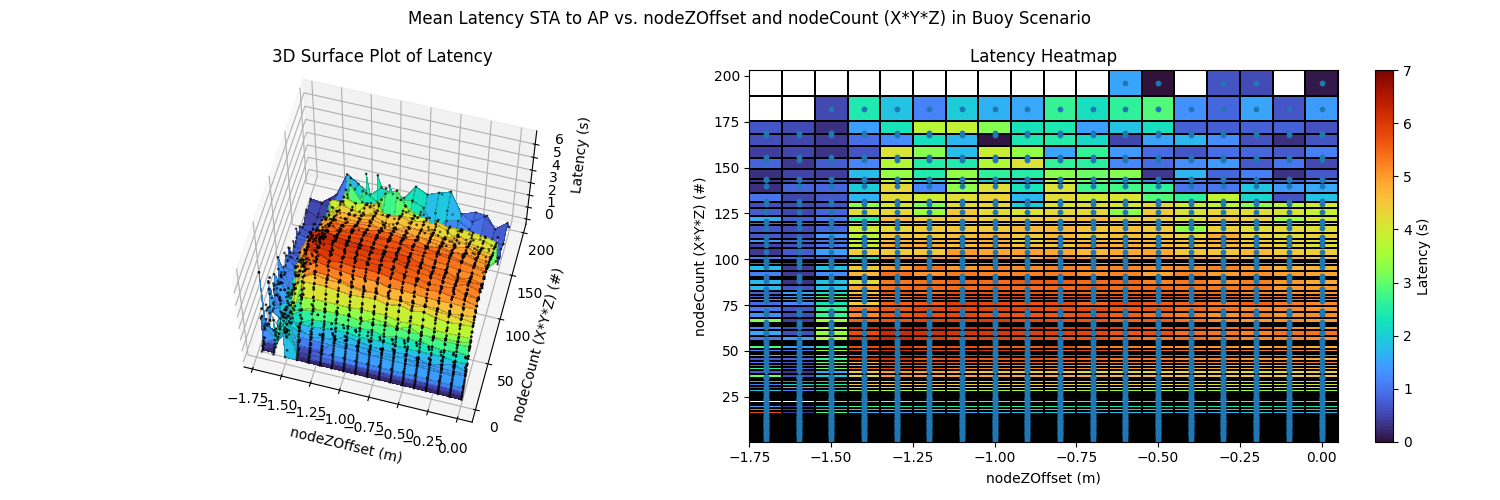

In [130]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean Latency STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(packet_flow_stats['nodeZOffset'].unique())
y_unique = np.sort((packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount']).unique())

# x_min, x_max = -2, -1.5
# y_min, y_max = 0, 50

# x_unique = x_unique[(x_unique >= x_min) & (x_unique <= x_max)]
# y_unique = y_unique[(y_unique >= y_min) & (y_unique <= y_max)]



X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (packet_flow_stats['nodeZOffset'] == node_z_offset) & \
               (packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = packet_flow_stats.loc[mask, 'Latency'].mean()
            if np.isnan(Z[j, i]):
                print(f"{node_z_offset}, {node_count} is a NaN, which implies that the nodes failed to connect (FlowMonitor file is empty)")
                Z[j, i] = np.inf
                #replace nans in the original data with the default value
                packet_flow_stats.loc[mask, 'Latency'] = np.inf
            else:
                Z[j, i] = Z[j, i] * 1e-9
        else:
            print(f"missing pair: {node_z_offset}, {node_count}, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)")
            Z[j, i] = np.nan

print("Max latency:", np.nanmin(Z))
print("Number of nans", np.isnan(Z).sum())  # Count NaNs
# Z = uniform_filter(Z, size=3)  # Adjust size for more smoothing
# print("Z_smooth shape: ", Z.dtype)
# print("Before smoothing:", Z)
# print("After smoothing:", Z_smooth)
# print("Min/Max after smoothing:", np.min(Z_smooth), np.max(Z_smooth))

# epsilon = 1e-6  # Small constant to avoid log(0)
# Z_log = np.log10(Z + epsilon)
# Z = Z_log

# Isometric view (default 3D view)
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='turbo',
                        edgecolor=(0,0,0,0.2),  # Lighter edges
                        linewidth=0.1,  # Thinner lines
                        antialiased=False,
                        shade=True,  # Enable shading
                        alpha=1,
                        vmin= 0,
                        vmax= 7)   # For smoother surface
ax1.view_init(elev=60, azim=-75)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Latency (s)')
ax1.set_title('3D Surface Plot of Latency')


#Overlay the actual data points
ax1.scatter(packet_flow_stats['nodeZOffset'], 
           packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'],
           packet_flow_stats['Latency'] * 1e-9,
           color='black', s=1, label='Data Points')  # s = marker size

# --- 2D Heatmap ---
ax2 = fig.add_subplot(122)  # Right side for 2D heatmap
# Calculate edges halfway between centers
x_edges = np.concatenate([
    [x_unique[0] - np.diff(x_unique)[0]/2],  # Left edge of first bin
    x_unique[:-1] + np.diff(x_unique)/2,      # Midpoints between centers
    [x_unique[-1] + np.diff(x_unique)[-1]/2]  # Right edge of last bin
])
y_edges = np.concatenate([
    [y_unique[0] - np.diff(y_unique)[0]/2],
    y_unique[:-1] + np.diff(y_unique)/2,
    [y_unique[-1] + np.diff(y_unique)[-1]/2]
])

# Create meshgrid for edges
X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

heatmap = ax2.pcolormesh(
    X_edges,  # Grid edges (x-axis)
    Y_edges,  # Grid edges (y-axis)
    Z,  
    cmap='turbo',
    shading='flat',  # Smooths irregular grids
    antialiased= False,
    edgecolors='black',  # Avoids gaps between cells
    linewidth=0.1,
    vmin=0,
    vmax= 7
)

ax2.set_xlabel("nodeZOffset (m)")
ax2.set_ylabel("nodeCount (X*Y*Z) (#)")
ax2.set_title("Latency Heatmap")
plt.colorbar(heatmap, ax=ax2, label='Latency (s)')


# Overlay the actual data points on the heatmap
# Ensure 'x' and 'y' values are compatible with the grid from X and Y meshgrid

#Overlay the actual data points
ax2.scatter(
    packet_flow_stats['nodeZOffset'],  # Filtered X values
    packet_flow_stats['nodeXCount'] * packet_flow_stats['nodeYCount'] * packet_flow_stats['nodeZCount'],  # Filtered Y values 
    s=10, 
    label='Data Points'
)


plt.tight_layout()
plt.show(block=True)



fig.savefig("Buoy_Latency_graphs.svg", format="svg", dpi=300)

range(0, 80, 5)
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  18.  20.  21.  22.  24.  25.  26.  27.  28.  30.  32.  33.
  35.  36.  39.  40.  42.  44.  45.  48.  49.  50.  52.  54.  55.  56.
  60.  63.  64.  65.  66.  70.  72.  77.  78.  80.  81.  84.  88.  90.
  91.  96.  98.  99. 100. 104. 108. 110. 112. 117. 120. 121. 126. 130.
 132. 140. 143. 144. 154. 156. 168. 169. 182. 196.]


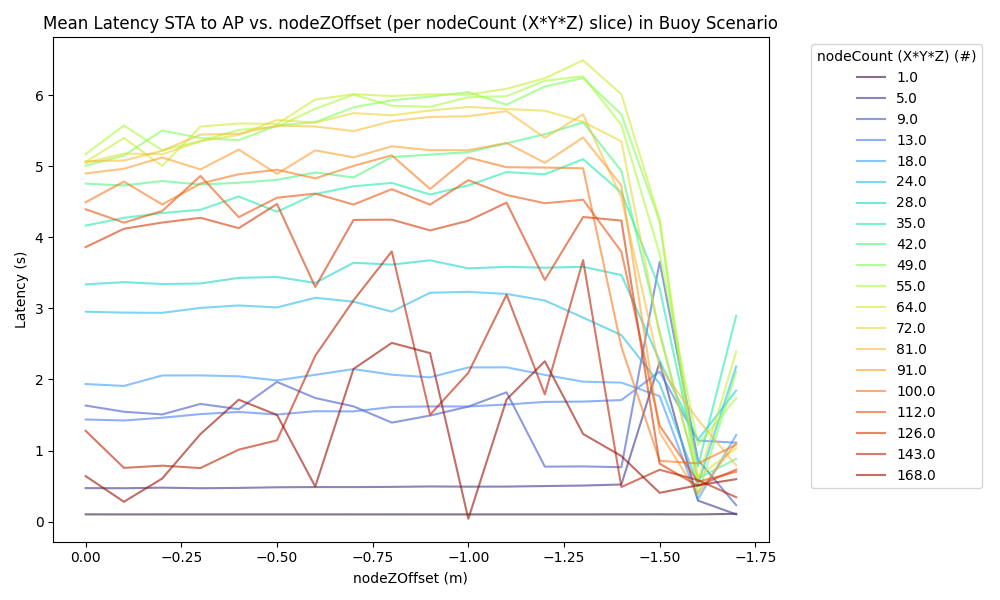

range(0, 18)
[-1.7 -1.6 -1.5 -1.4 -1.3 -1.2 -1.1 -1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4
 -0.3 -0.2 -0.1  0. ]


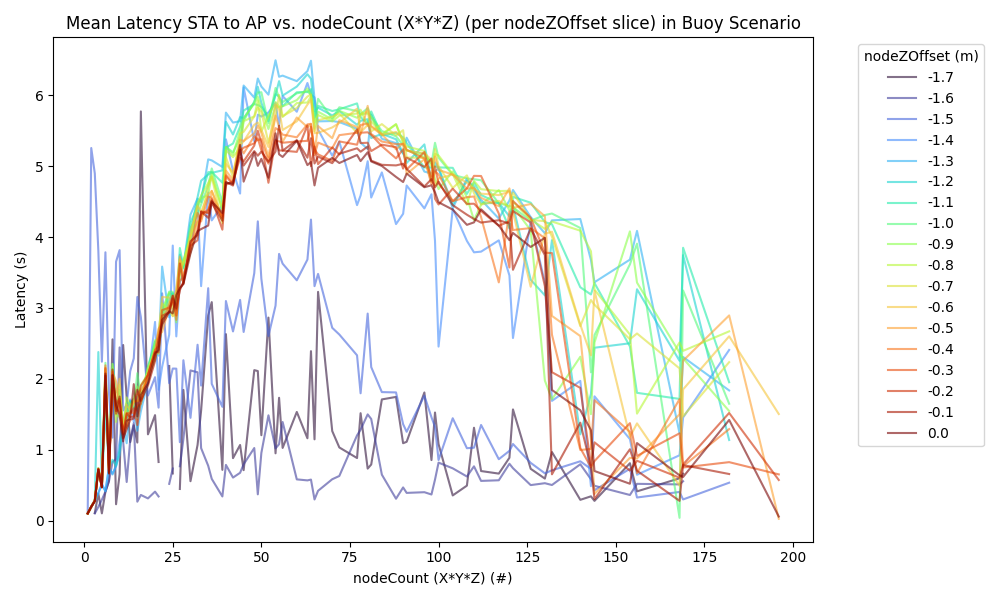

In [131]:
import matplotlib.cm as cm
fig, ax2d = plt.subplots(figsize=(10, 6))

# Use a colormap to assign colors to each slice
colors = cm.turbo(np.linspace(0, 1, len(y_unique)))

# Plot every 5th Y-slice (temperature or whatever Y is)
print(range(0, len(y_unique), 5))
print(y_unique)
for i in range(0, len(y_unique), 4):
    ax2d.plot(
        x_unique,              # X-axis values
        Z[i, :],               # Corresponding Z values for this Y
        color=colors[i],       # Color from colormap
        alpha=0.6,             # Transparency to reduce clutter
        label=f'{y_unique[i]:.1f}'  # Label for legend
    )

# Add labels and title
ax2d.set_xlabel('nodeZOffset (m)')
ax2d.set_ylabel('Latency (s)')
#Mean Power Usage STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario
ax2d.set_title('Mean Latency STA to AP vs. nodeZOffset (per nodeCount (X*Y*Z) slice) in Buoy Scenario')

# Add a legend (limited to 1 label every 5 lines)
ax2d.legend(title='nodeCount (X*Y*Z) (#)', bbox_to_anchor=(1.05, 1), loc='upper left')

ax2d.invert_xaxis()

plt.tight_layout()
plt.show()

import matplotlib.cm as cm
fig, ax3d = plt.subplots(figsize=(10, 6))

# Use a colormap to assign colors to each slice
colors = cm.turbo(np.linspace(0, 1, len(x_unique)))

# Plot every 5th Y-slice (temperature or whatever Y is)
print(range(0, len(x_unique), 1))
print(x_unique)
for i in range(0, len(x_unique), 1):
    ax3d.plot(
        y_unique,              # X-axis values
        Z[:, i],               # Corresponding Z values for this Y
        color=colors[i],       # Color from colormap
        alpha=0.6,             # Transparency to reduce clutter
        label=f'{x_unique[i]:.1f}'  # Label for legend
    )

# Add labels and title
ax3d.set_xlabel('nodeCount (X*Y*Z) (#)')
ax3d.set_ylabel('Latency (s)')
ax3d.set_title('Mean Latency STA to AP vs. nodeCount (X*Y*Z) (per nodeZOffset slice) in Buoy Scenario')

# Add a legend (limited to 1 label every 5 lines)
ax3d.legend(title='nodeZOffset (m)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [77]:
power_state_stats['TotalPower'] = power_state_stats['TotalEnergy'] / power_state_stats['stopTime'] # Convert to W

missing pair: -1.7000000000000002, 182.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.7000000000000002, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.6, 182.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.6, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.5, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.4000000000000001, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.3, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.2000000000000002, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.1, 196.0, w

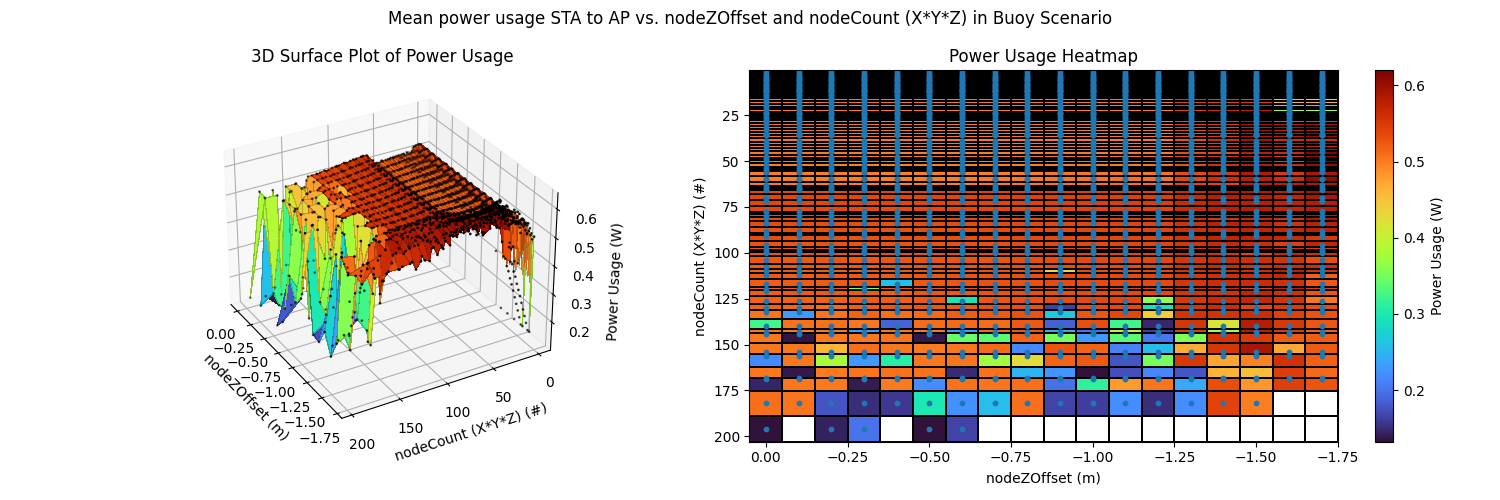

In [ ]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean power usage STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(power_state_stats['nodeZOffset'].unique())
y_unique = np.sort((power_state_stats['nodeXCount'] * power_state_stats['nodeYCount'] * power_state_stats['nodeZCount']).unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (power_state_stats['nodeZOffset'] == node_z_offset) & \
               (power_state_stats['nodeXCount'] * power_state_stats['nodeYCount'] * power_state_stats['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = power_state_stats.loc[mask, 'TotalPower'].mean()
            if np.isnan(Z[j, i]):
                print(f"{node_z_offset}, {node_count} is a NaN, which implies that the nodes failed to connect (FlowMonitor file is empty)")
        else:
            print(f"missing pair: {node_z_offset}, {node_count}, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)")
            Z[j, i] = np.nan


print("Number of nans", np.isnan(Z).sum())  # Count NaNs
#Z = uniform_filter(Z, size=3)  # Adjust size for more smoothing
# print("Z_smooth shape: ", Z.dtype)
# print("Before smoothing:", Z)
# print("After smoothing:", Z_smooth)
# print("Min/Max after smoothing:", np.min(Z_smooth), np.max(Z_smooth))

# epsilon = 1e-6  # Small constant to avoid log(0)
# Z_log = np.log10(Z + epsilon)
# Z = Z_log


# Isometric view (default 3D view)
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='turbo',
                        edgecolor=(0,0,0,0.2),  # Lighter edges
                        linewidth=0.1,  # Thinner lines
                        antialiased=False,
                        shade=True,  # Enable shading
                        alpha=1)   # For smoother surface
ax1.view_init(elev=30, azim=150)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Power Usage (W)')
ax1.set_title('3D Surface Plot of Power Usage')

# Overlay the actual data points
ax1.scatter(power_state_stats['nodeZOffset'], 
           power_state_stats['nodeXCount'] * power_state_stats['nodeYCount'] * power_state_stats['nodeZCount'],
           power_state_stats['TotalPower'],
           color='black', s=1, label='Data Points')  # s = marker size



# --- 2D Heatmap ---
ax2 = fig.add_subplot(122)  # Right side for 2D heatmap
# Calculate edges halfway between centers
x_edges = np.concatenate([
    [x_unique[0] - np.diff(x_unique)[0]/2],  # Left edge of first bin
    x_unique[:-1] + np.diff(x_unique)/2,      # Midpoints between centers
    [x_unique[-1] + np.diff(x_unique)[-1]/2]  # Right edge of last bin
])
y_edges = np.concatenate([
    [y_unique[0] - np.diff(y_unique)[0]/2],
    y_unique[:-1] + np.diff(y_unique)/2,
    [y_unique[-1] + np.diff(y_unique)[-1]/2]
])


# Create meshgrid for edges
X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

heatmap = ax2.pcolormesh(
    X_edges,  # Grid edges (x-axis)
    Y_edges,  # Grid edges (y-axis)
    Z,  
    cmap='turbo',
    shading='flat',  # Smooths irregular grids
    antialiased= False,
    edgecolors='black',  # Avoids gaps between cells
    linewidth=0.1,
)

ax2.set_xlabel("nodeZOffset (m)")
ax2.set_ylabel("nodeCount (X*Y*Z) (#)")
ax2.set_title("Power Usage Heatmap")
ax2.invert_xaxis()
ax2.invert_yaxis()
plt.colorbar(heatmap, ax=ax2, label='Power Usage (W)')


# Overlay the actual data points on the heatmap
# Ensure 'x' and 'y' values are compatible with the grid from X and Y meshgrid

#Overlay the actual data points
ax2.scatter(
    power_state_stats['nodeZOffset'],  # Filtered X values
    power_state_stats['nodeXCount'] * power_state_stats['nodeYCount'] * power_state_stats['nodeZCount'],  # Filtered Y values 
    s=10, 
    label='Data Points'
)

plt.tight_layout()
plt.show(block=True)

fig.savefig("Buoy_Power_Usage_graphs.svg", format="svg", dpi=300)

range(0, 80, 5)
[  1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.
  15.  16.  18.  20.  21.  22.  24.  25.  26.  27.  28.  30.  32.  33.
  35.  36.  39.  40.  42.  44.  45.  48.  49.  50.  52.  54.  55.  56.
  60.  63.  64.  65.  66.  70.  72.  77.  78.  80.  81.  84.  88.  90.
  91.  96.  98.  99. 100. 104. 108. 110. 112. 117. 120. 121. 126. 130.
 132. 140. 143. 144. 154. 156. 168. 169. 182. 196.]


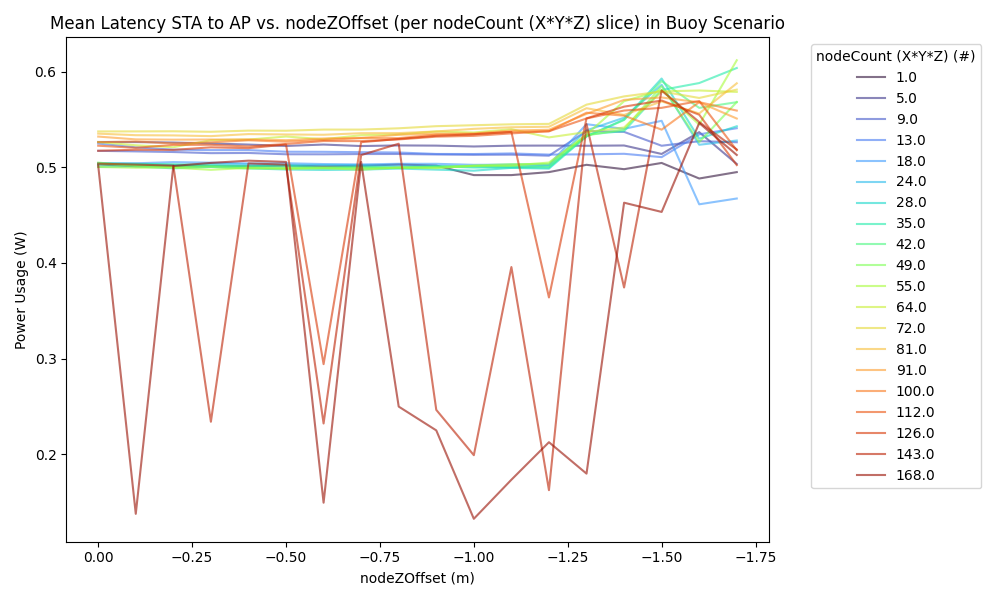

range(0, 18)
[-1.7 -1.6 -1.5 -1.4 -1.3 -1.2 -1.1 -1.  -0.9 -0.8 -0.7 -0.6 -0.5 -0.4
 -0.3 -0.2 -0.1  0. ]


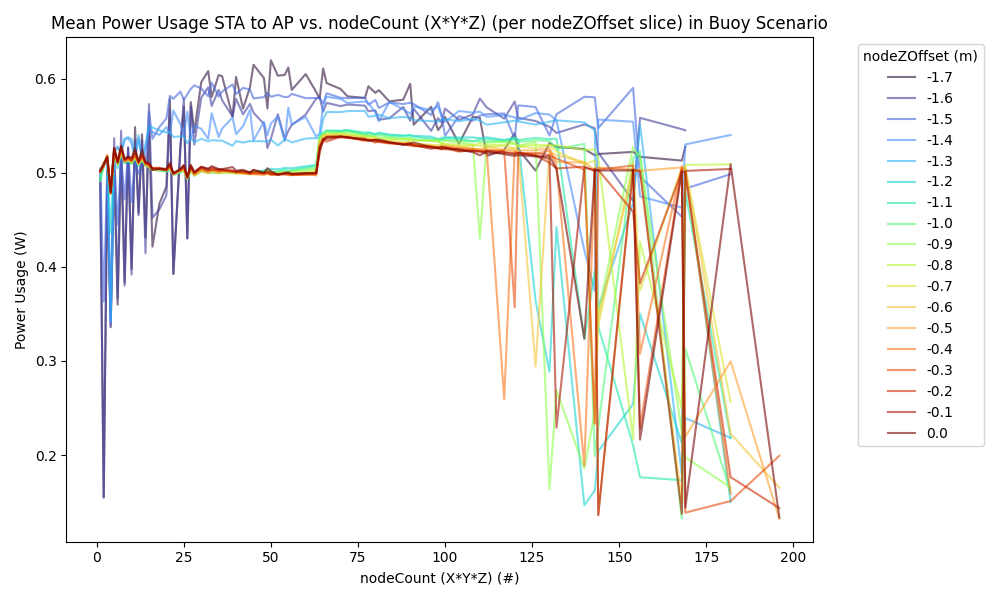

In [ ]:
import matplotlib.cm as cm
fig, ax2d = plt.subplots(figsize=(10, 6))

# Use a colormap to assign colors to each slice
colors = cm.turbo(np.linspace(0, 1, len(y_unique)))

# Plot every 4th Y-slice (temperature or whatever Y is)
for i in range(0, len(y_unique), 4):
    ax2d.plot(
        x_unique,              # X-axis values
        Z[i, :],               # Corresponding Z values for this Y
        color=colors[i],       # Color from colormap
        alpha=0.6,             # Transparency to reduce clutter
        label=f'{y_unique[i]:.1f}'  # Label for legend
    )

# Add labels and title
ax2d.set_xlabel('nodeZOffset (m)')
ax2d.set_ylabel('Power Usage (W)')
#Mean Power Usage STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario
ax2d.set_title('Mean Power Usage STA to AP vs. nodeZOffset (per nodeCount (X*Y*Z) slice) in Buoy Scenario')

# Add a legend (limited to 1 label every 5 lines)
ax2d.legend(title='nodeCount (X*Y*Z) (#)', bbox_to_anchor=(1.05, 1), loc='upper left')

ax2d.invert_xaxis()

plt.tight_layout()
plt.show()


fig, ax3d = plt.subplots(figsize=(10, 6))

# Use a colormap to assign colors to each slice
colors = cm.turbo(np.linspace(0, 1, len(x_unique)))

# Plot every Y-slice (temperature or whatever Y is)
for i in range(0, len(x_unique), 1):
    ax3d.plot(
        y_unique,              # X-axis values
        Z[:, i],               # Corresponding Z values for this Y
        color=colors[i],       # Color from colormap
        alpha=0.6,             # Transparency to reduce clutter
        label=f'{x_unique[i]:.1f}'  # Label for legend
    )

# Add labels and title
ax3d.set_xlabel('nodeCount (X*Y*Z) (#)')
ax3d.set_ylabel('Power Usage (W)')
ax3d.set_title('Mean Power Usage STA to AP vs. nodeCount (X*Y*Z) (per nodeZOffset slice) in Buoy Scenario')

# Add a legend (limited to 1 label every 5 lines)
ax3d.legend(title='nodeZOffset (m)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [79]:
# Merge the two dataframes on all config columns based on the last scenario folder's config
config_columns = list(sim_config.keys())
merged_stats = pd.merge(packet_flow_stats, power_state_stats, on=config_columns)

merged_stats["EnergyEfficiency"] = merged_stats["rxBytes"] * 8 / merged_stats["TotalEnergy"]

missing pair: -1.7000000000000002, 182.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.7000000000000002, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.6, 182.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.6, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.5, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.4000000000000001, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.3, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.2000000000000002, 196.0, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)
missing pair: -1.1, 196.0, w

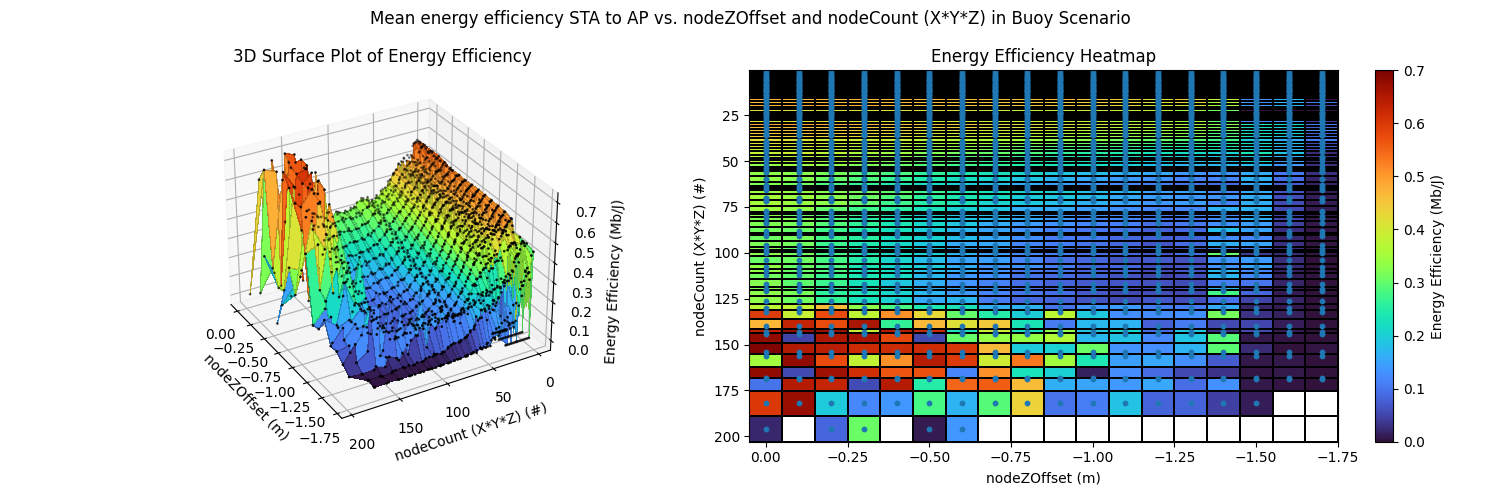

In [138]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean energy efficiency STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Create a 2D grid for surface plot
x_unique = np.sort(merged_stats['nodeZOffset'].unique())
y_unique = np.sort((merged_stats['nodeXCount'] * merged_stats['nodeYCount'] * merged_stats['nodeZCount']).unique())

X, Y = np.meshgrid(x_unique, y_unique)
Z = np.zeros(X.shape)

# Map data to grid
for i in range(len(x_unique)):
    for j in range(len(y_unique)):
        node_z_offset = x_unique[i]
        node_count = y_unique[j]
        mask = (merged_stats['nodeZOffset'] == node_z_offset) & \
               (merged_stats['nodeXCount'] * merged_stats['nodeYCount'] * merged_stats['nodeZCount'] == node_count)
        if mask.any():
            Z[j, i] = merged_stats.loc[mask, 'EnergyEfficiency'].mean()
            if np.isnan(Z[j, i]):
                print(f"{node_z_offset}, {node_count} is a NaN, which implies that the nodes failed to connect (FlowMonitor file is empty)")
            else:
                Z[j, i] = Z[j, i] * 1e-6
        else:
            print(f"missing pair: {node_z_offset}, {node_count}, which implies that the simulation failed or didn't run (FlowMonitor file non-existent)")
            Z[j, i] = np.nan
                


print("Number of nans", np.isnan(Z).sum())  # Count NaNs
#Z = uniform_filter(Z, size=3)  # Adjust size for more smoothing
# print("Z_smooth shape: ", Z.dtype)
# print("Before smoothing:", Z)
# print("After smoothing:", Z_smooth)
# print("Min/Max after smoothing:", np.min(Z_smooth), np.max(Z_smooth))

# epsilon = 1e-6  # Small constant to avoid log(0)
# Z_log = np.log10(Z + epsilon)
# Z = Z_log


# Isometric view (default 3D view)
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='turbo',
                        edgecolor=(0,0,0,0.2),  # Lighter edges
                        linewidth=0.1,  # Thinner lines
                        antialiased=False,
                        shade=True,  # Enable shading
                        alpha=1,
                        vmin= 0,
                        vmax= 0.7)   # For smoother surface
ax1.view_init(elev=30, azim=150)
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Energy Efficiency (Mb/J)')
ax1.set_title('3D Surface Plot of Energy Efficiency')

# Overlay the actual data points
ax1.scatter(merged_stats['nodeZOffset'], 
           merged_stats['nodeXCount'] * merged_stats['nodeYCount'] * merged_stats['nodeZCount'],
           merged_stats['EnergyEfficiency'] * 1e-6,
           color='black', s=1, label='Data Points')  # s = marker size

# --- 2D Heatmap ---
ax2 = fig.add_subplot(122)  # Right side for 2D heatmap
# Calculate edges halfway between centers
x_edges = np.concatenate([
    [x_unique[0] - np.diff(x_unique)[0]/2],  # Left edge of first bin
    x_unique[:-1] + np.diff(x_unique)/2,      # Midpoints between centers
    [x_unique[-1] + np.diff(x_unique)[-1]/2]  # Right edge of last bin
])
y_edges = np.concatenate([
    [y_unique[0] - np.diff(y_unique)[0]/2],
    y_unique[:-1] + np.diff(y_unique)/2,
    [y_unique[-1] + np.diff(y_unique)[-1]/2]
])


# Create meshgrid for edges
X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

heatmap = ax2.pcolormesh(
    X_edges,  # Grid edges (x-axis)
    Y_edges,  # Grid edges (y-axis)
    Z,  
    cmap='turbo',
    shading='flat',  # Smooths irregular grids
    antialiased= False,
    edgecolors='black',  # Avoids gaps between cells
    linewidth=0.1,
    vmin= 0,
    vmax= 0.7
)

ax2.set_xlabel("nodeZOffset (m)")
ax2.set_ylabel("nodeCount (X*Y*Z) (#)")
ax2.set_title("Energy Efficiency Heatmap")
ax2.invert_xaxis()
ax2.invert_yaxis()
plt.colorbar(heatmap, ax=ax2, label='Energy Efficiency (Mb/J)')


# Overlay the actual data points on the heatmap
# Ensure 'x' and 'y' values are compatible with the grid from X and Y meshgrid

#Overlay the actual data points
ax2.scatter(
    merged_stats['nodeZOffset'],  # Filtered X values
    merged_stats['nodeXCount'] * merged_stats['nodeYCount'] * merged_stats['nodeZCount'],  # Filtered Y values 
    s=10, 
    label='Data Points'
)

plt.tight_layout()
plt.show(block=True)

fig.savefig("Buoy_Energy_Efficiency_graphs.svg", format="svg", dpi=300)

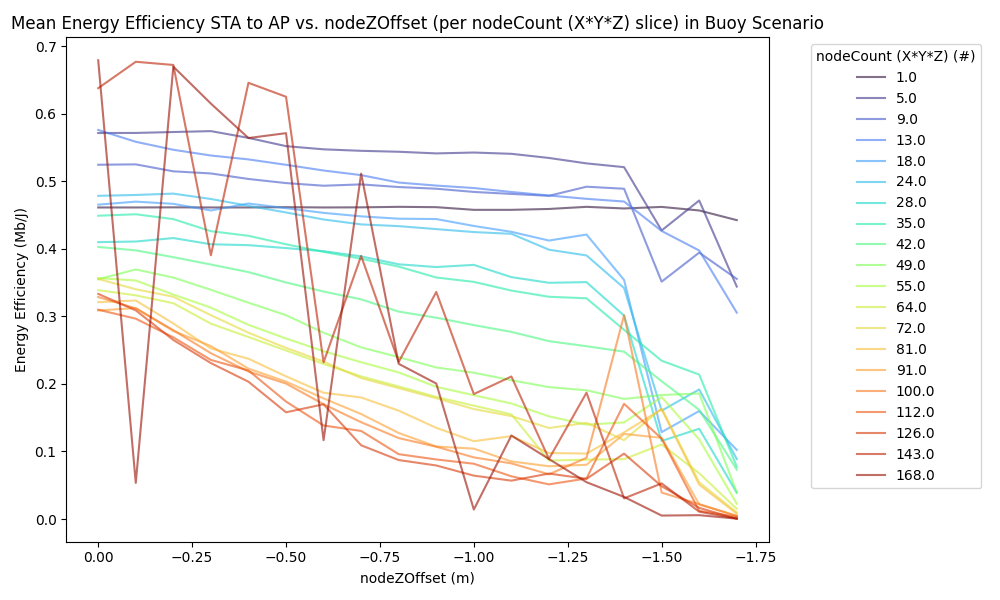

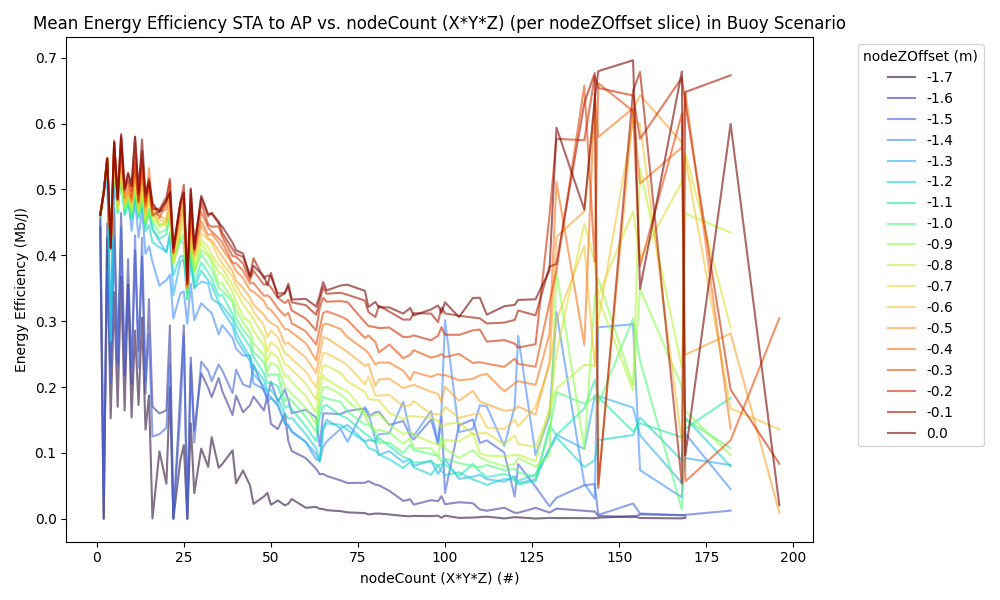

In [140]:
import matplotlib.cm as cm
fig, ax2d = plt.subplots(figsize=(10, 6))

# Use a colormap to assign colors to each slice
colors = cm.turbo(np.linspace(0, 1, len(y_unique)))

# Plot every 4th Y-slice (temperature or whatever Y is)
for i in range(0, len(y_unique), 4):
    ax2d.plot(
        x_unique,              # X-axis values
        Z[i, :],               # Corresponding Z values for this Y
        color=colors[i],       # Color from colormap
        alpha=0.6,             # Transparency to reduce clutter
        label=f'{y_unique[i]:.1f}'  # Label for legend
    )

# Add labels and title
ax2d.set_xlabel('nodeZOffset (m)')
ax2d.set_ylabel('Energy Efficiency (Mb/J)')
#Mean Power Usage STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario
ax2d.set_title('Mean Energy Efficiency STA to AP vs. nodeZOffset (per nodeCount (X*Y*Z) slice) in Buoy Scenario')

# Add a legend (limited to 1 label every 5 lines)
ax2d.legend(title='nodeCount (X*Y*Z) (#)', bbox_to_anchor=(1.05, 1), loc='upper left')

ax2d.invert_xaxis()

plt.tight_layout()
plt.show()


fig, ax3d = plt.subplots(figsize=(10, 6))

# Use a colormap to assign colors to each slice
colors = cm.turbo(np.linspace(0, 1, len(x_unique)))

# Plot every Y-slice (temperature or whatever Y is)
for i in range(0, len(x_unique), 1):
    ax3d.plot(
        y_unique,              # X-axis values
        Z[:, i],               # Corresponding Z values for this Y
        color=colors[i],       # Color from colormap
        alpha=0.6,             # Transparency to reduce clutter
        label=f'{x_unique[i]:.1f}'  # Label for legend
    )

# Add labels and title
ax3d.set_xlabel('nodeCount (X*Y*Z) (#)')
ax3d.set_ylabel('Energy Efficiency (Mb/J)')
ax3d.set_title('Mean Energy Efficiency STA to AP vs. nodeCount (X*Y*Z) (per nodeZOffset slice) in Buoy Scenario')

# Add a legend (limited to 1 label every 5 lines)
ax3d.legend(title='nodeZOffset (m)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()